In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv(r"C:\Users\deeks\OneDrive\Desktop\ML\insurance.csv")

In [28]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [29]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [49]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [31]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [33]:
df.shape

(1338, 7)

In [34]:
target = "tip"

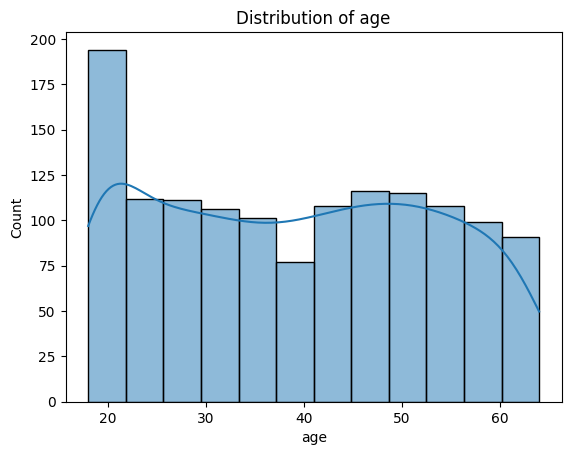

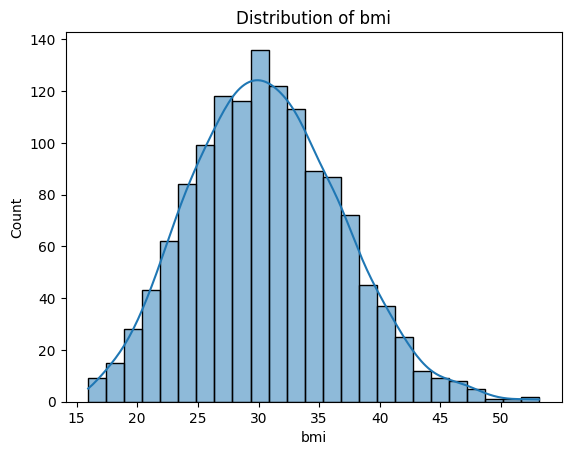

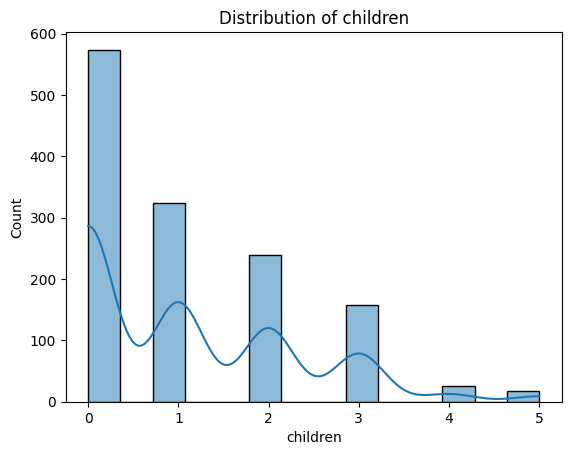

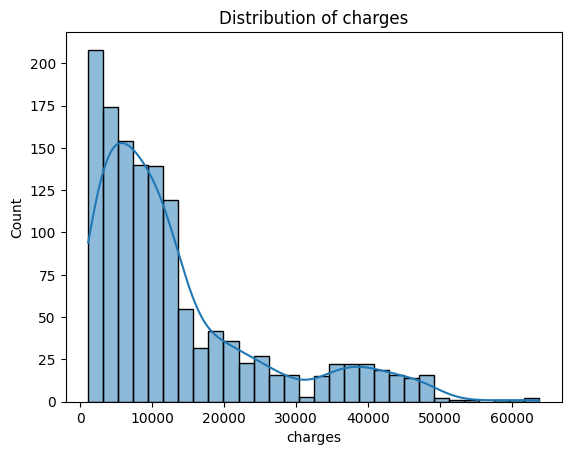

In [41]:

import matplotlib.pyplot as plt

numerical_cols = ['age','bmi','children','charges']

for col in numerical_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()
    

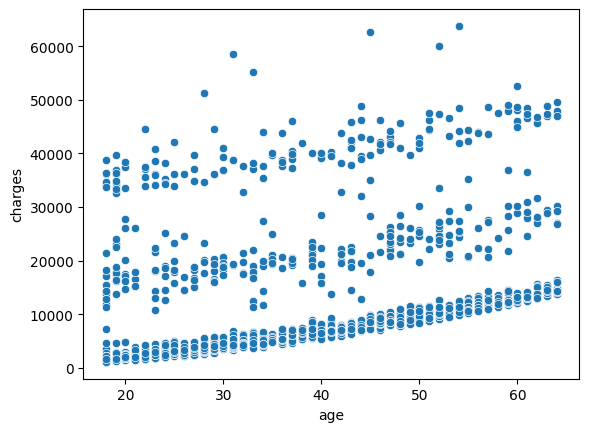

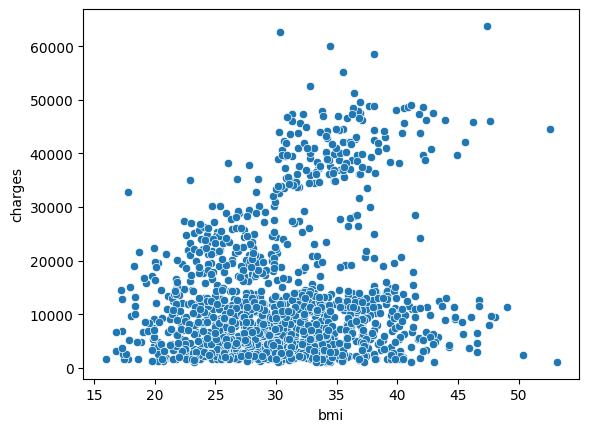

In [36]:
sns.scatterplot(x="age", y="charges", data=df)
plt.show()

sns.scatterplot(x="bmi", y="charges", data=df)
plt.show()

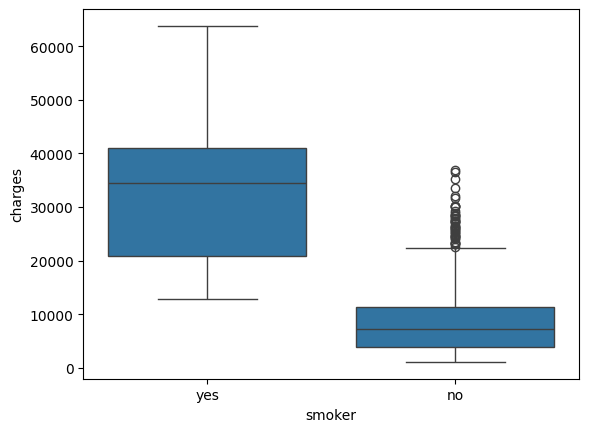

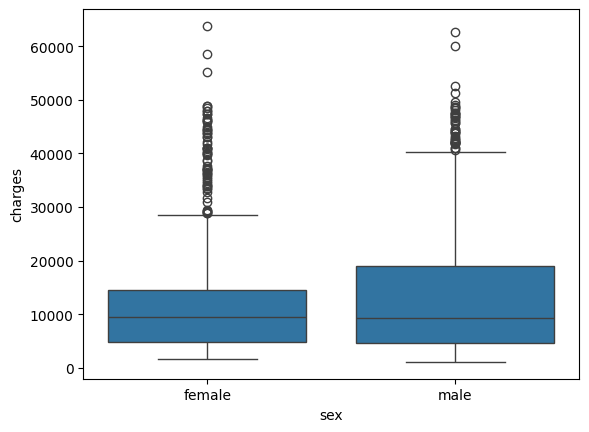

In [37]:
sns.boxplot(x="smoker", y="charges", data=df)
plt.show()

sns.boxplot(x="sex", y="charges", data=df)
plt.show()

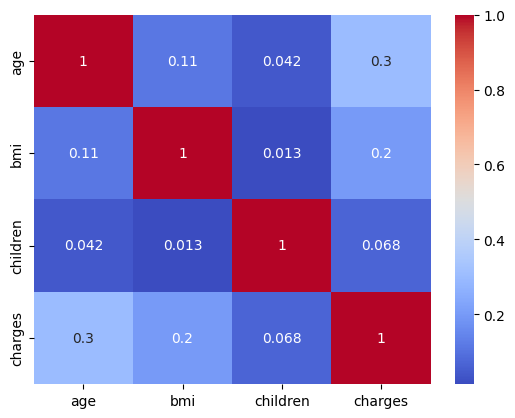

In [38]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

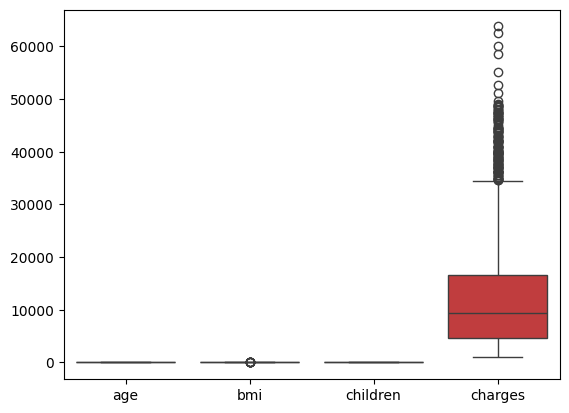

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df[['age','bmi','children','charges']])
plt.show()

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df[['bmi']]
Y = df['charges']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [45]:
from sklearn.metrics import r2_score, mean_squared_error

Y_pred = model.predict(X_test)

print("Slope:", model.coef_)
print("Intercept:", model.intercept_)

print("R2 Score:", r2_score(Y_test, Y_pred))
print("MSE:", mean_squared_error(Y_test, Y_pred))

Slope: [392.43654417]
Intercept: 1353.0730722046574
R2 Score: 0.03970193117941878
MSE: 149085057.03839505


In [47]:
import numpy as np

X_values = df['bmi']
Y_values = df['charges']

cov = np.cov(X_values, Y_values, bias=True)[0][1]
var = np.var(X_values)

manual_slope = cov / var

print("Manual Slope:", manual_slope)



Manual Slope: 393.8730307973952


In [48]:
print("Library Slope:", model.coef_[0])
print("Manual Slope:", manual_slope)

Library Slope: 392.4365441698801
Manual Slope: 393.8730307973952


<Axes: >

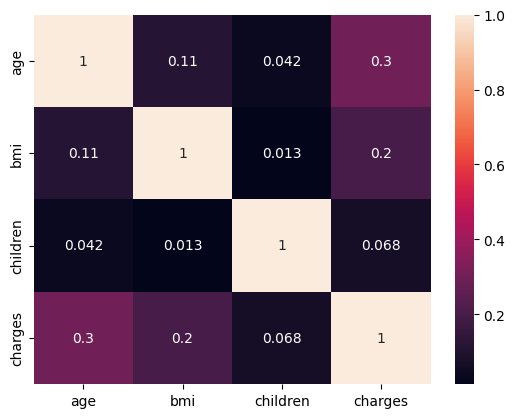

In [50]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [51]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df['bmi'] < lower_limit) | (df['bmi'] > upper_limit)]

print(outliers)

      age     sex    bmi  children smoker     region      charges
116    58    male  49.06         0     no  southeast  11381.32540
286    46  female  48.07         2     no  northeast   9432.92530
401    47    male  47.52         1     no  southeast   8083.91980
543    54  female  47.41         0    yes  southeast  63770.42801
847    23    male  50.38         1     no  southeast   2438.05520
860    37  female  47.60         2    yes  southwest  46113.51100
1047   22    male  52.58         1    yes  southeast  44501.39820
1088   52    male  47.74         1     no  southeast   9748.91060
1317   18    male  53.13         0     no  southeast   1163.46270


In [52]:
from sklearn.metrics import r2_score, mean_squared_error

Y_pred = model.predict(X_test)

print("R2 Score:", r2_score(Y_test, Y_pred))
print("MSE:", mean_squared_error(Y_test, Y_pred))

R2 Score: 0.03970193117941878
MSE: 149085057.03839505


In [54]:
df.isnull()

,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False
